# Divvy 共享单车时空分析(芝加哥 2025)

**数据**:Divvy 官方开放数据(全年真实骑行记录,PySpark 清洗后的 DWD 明细 + ADS 指标层)
**工具**:pandas · PySpark(离线管道)· matplotlib

本笔记本聚焦 **探索性分析(EDA)**:数据质量 → 季节性 → 分时规律 → 站点与流向 → 用户与车型。
大数据量的清洗与聚合由 PySpark 脚本(`01_clean_etl.py` / `02_build_metrics.py`)完成,
笔记本负责交互式探索与结论产出。

In [1]:
import os, json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

YEAR = 2025
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "./warehouse"))
ADS = DATA_ROOT / "ads"

for f in glob.glob("/usr/share/fonts/**/*.tt[fc]", recursive=True):
    try: font_manager.fontManager.addfont(f)
    except Exception: pass
avail = {f.name for f in font_manager.fontManager.ttflist}
for name in ["Noto Sans SC", "WenQuanYi Zen Hei", "Noto Serif SC", "LXGW WenKai"]:
    if name in avail:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]; break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.color"] = "#E5E7EB"

CBLUE, CAMBER, CGREEN, CPURPLE = "#1D4ED8", "#F59E0B", "#059669", "#7C3AED"
DOW = ["周一","周二","周三","周四","周五","周六","周日"]
def load(name): return pd.read_json(ADS / f"{name}.json")
kpi, cube, monthly, daily = load("kpi").iloc[0], load("cube"), load("monthly"), load("daily")
stations, od, dur = load("stations"), load("od"), load("dur_hist")
print(f"ADS 指标层加载完成:cube {len(cube)} 行,stations {len(stations)} 站,od {len(od)} 对")

ADS 指标层加载完成:cube 8060 行,stations 3360 站,od 1000 对


## 1. 数据质量(PySpark ETL 输出)

In [2]:
quality = json.load(open(DATA_ROOT / "dwd" / "_quality.json", encoding="utf-8"))
pd.Series(quality).to_frame("value")

,value
year,2025
n_raw,5552994
n_distinct_ride_id,5552994
dropped_bad_time,0
dropped_bad_duration,5614
dropped_bad_enum,0
n_duplicate_rides,0
n_clean,5547380
drop_rate_pct,0.101
rules,"{'duration': '(0, 1440] 分钟', 'dup': 'ride_id 去..."


清洗规则:时长 ∈ (0, 1440] 分钟、关键字段非空、`ride_id` 去重;
站点/坐标缺失保留(站点级分析时过滤)。**原始 → 干净**的记录数变化即上表。

## 2. 明细样本:1 月 vs 7 月

In [3]:
DWD_PATH = DATA_ROOT / "dwd"
if DWD_PATH.exists():
    detail = pd.read_parquet(DWD_PATH, filters=[("month", "in", [1, 7])])
    print(f"已加载 DWD 全量明细(1月/7月): {detail.shape[0]:,} 行 × {detail.shape[1]} 列")
else:
    detail = pd.read_parquet("data/sample/dwd_sample.parquet")
    print("未找到 warehouse/dwd,使用仓库自带样本(data/sample/dwd_sample.parquet)")
detail.head(3)

已加载 DWD 全量明细(1月/7月): 901,074 行 × 20 列


,ride_id,rideable_type,member_casual,started_ts,ended_ts,duration_min,date,hour,dow,day_type,start_station_id,start_station_name,start_lat,start_lng,end_station_id,end_station_name,end_lat,end_lng,year,month
0,00026D05EBE1B7F5,electric_bike,member,2025-01-31 08:40:10.415,2025-01-31 08:49:51.056,9.683333,2025-01-31,16,5,工作日,13080,Hermitage Ave & Polk St,41.871514,-87.669886,638,Clinton St & Jackson Blvd,41.878317,-87.640981,2025,1
1,00030B37E0C19315,electric_bike,member,2025-01-09 03:44:21.386,2025-01-09 03:54:43.255,10.366667,2025-01-09,11,4,工作日,13074,Broadway & Wilson Ave,41.965221,-87.658139,NaN,NaN,41.950000,-87.670000,2025,1
2,0007F126E57E09E7,electric_bike,member,2025-01-29 08:25:27.051,2025-01-29 08:35:29.979,10.033333,2025-01-29,16,3,工作日,638,Clinton St & Jackson Blvd,41.878317,-87.640981,15534,Field Blvd & South Water St,41.886349,-87.617517,2025,1


In [4]:
detail["duration_min"].describe().to_frame("duration_min").round(2)

,duration_min
count,901074.00
mean,15.19
std,29.89
min,0.02
25%,5.55
50%,9.75
75%,17.13
max,1439.75


In [5]:
detail.groupby("member_casual")["duration_min"].agg(["count", "mean", "median"]).round(1)

,count,mean,median
member_casual,,,
casual,346605,19.9,11.9
member,554469,12.2,8.8


**观察**:散客的中位/平均时长都明显高于会员——会员通勤高频短途,散客休闲低频长途。这是全年结构在样本月中的体现。

## 3. 季节性

findfont: Failed to find font weight normal for WenQuanYi Zen Hei, now using 500.


findfont: Failed to find font weight normal for WenQuanYi Zen Hei, now using 500.


findfont: Failed to find font weight normal for WenQuanYi Zen Hei, now using 500.


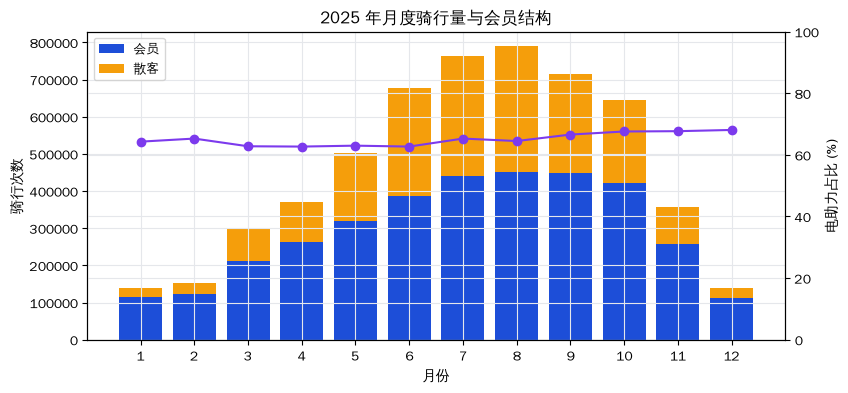

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly.month, monthly.n_member, color=CBLUE, label="会员")
ax.bar(monthly.month, monthly.n_casual, bottom=monthly.n_member, color=CAMBER, label="散客")
ax2 = ax.twinx(); ax2.plot(monthly.month, monthly.electric_share, color=CPURPLE, marker="o", label="电助力占比")
ax2.set_ylabel("电助力占比 (%)"); ax2.set_ylim(0, 100)
ax.set_xlabel("月份"); ax.set_ylabel("骑行次数"); ax.set_xticks(monthly.month)
ax.set_title(f"{YEAR} 年月度骑行量与会员结构"); ax.legend(loc="upper left", fontsize=9)
plt.show()

In [7]:
peak = monthly.loc[monthly.n.idxmax()]
low = monthly.loc[monthly.n.idxmin()]
print(f"峰值 {int(peak.month)} 月 {peak.n:,.0f} 次;低谷 {int(low.month)} 月 {low.n:,.0f} 次,比值 {peak.n/low.n:.1f}")

峰值 8 月 789,475 次;低谷 1 月 138,620 次,比值 5.7


## 4. 分时规律:通勤双峰 vs 周末单峰

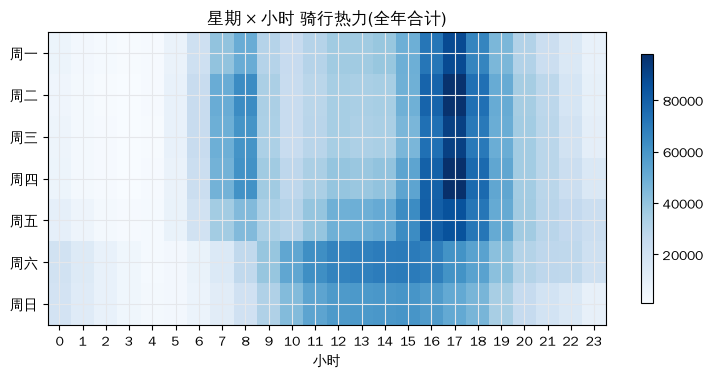

In [8]:
hm = np.zeros((7, 24))
for r in cube.itertuples(): hm[r.dow-1, r.hour] += r.n
fig, ax = plt.subplots(figsize=(9, 3.8))
im = ax.imshow(hm, aspect="auto", cmap="Blues")
ax.set_xticks(range(24)); ax.set_yticks(range(7), DOW)
ax.set_xlabel("小时"); ax.set_title("星期 × 小时 骑行热力(全年合计)")
fig.colorbar(im, ax=ax, shrink=.85); plt.show()

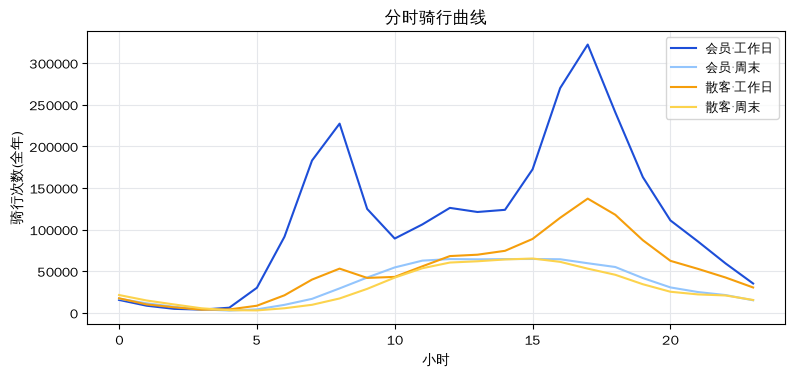

In [9]:
hc = cube.groupby(["member","dow","hour"], as_index=False).n.sum()
hc["weekend"] = hc.dow >= 6
piv = hc.pivot_table(index="hour", columns=["member","weekend"], values="n", aggfunc="sum")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(piv.index, piv[("member",False)], color=CBLUE, label="会员·工作日")
ax.plot(piv.index, piv[("member",True)], color="#93C5FD", label="会员·周末")
ax.plot(piv.index, piv[("casual",False)], color=CAMBER, label="散客·工作日")
ax.plot(piv.index, piv[("casual",True)], color="#FCD34D", label="散客·周末")
ax.set_xlabel("小时"); ax.set_ylabel("骑行次数(全年)")
ax.set_title("分时骑行曲线"); ax.legend(fontsize=9); plt.show()

## 5. 站点与流向

findfont: Failed to find font weight normal for WenQuanYi Zen Hei, now using 500.


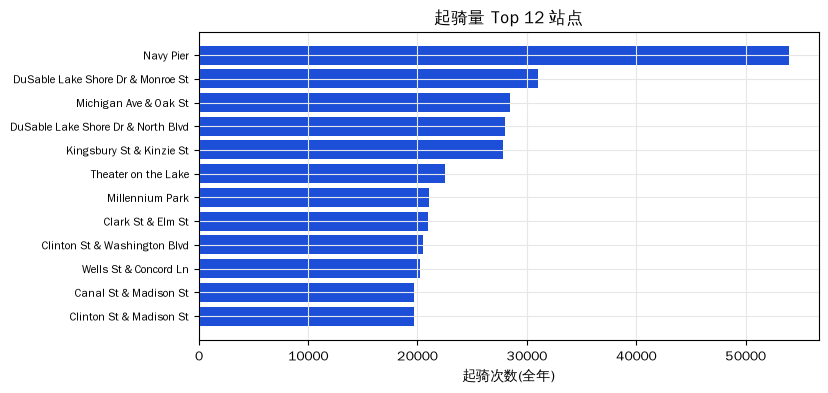

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
st = stations.sort_values("starts", ascending=False).head(12).iloc[::-1]
ax.barh(st.name, st.starts, color=CBLUE); ax.set_xlabel("起骑次数(全年)")
ax.set_title("起骑量 Top 12 站点"); plt.setp(ax.get_yticklabels(), fontsize=8); plt.show()

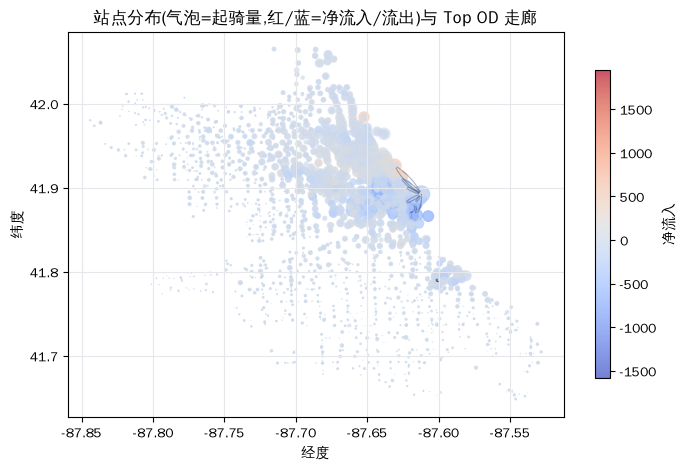

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(stations.lng, stations.lat, s=np.sqrt(stations.starts)*.7,
                c=stations.net, cmap="coolwarm", alpha=.7, linewidths=0)
for r in od.head(34).itertuples():
    ax.annotate("", xy=(r.e_lng, r.e_lat), xytext=(r.s_lng, r.s_lat),
                arrowprops=dict(arrowstyle="-", color="#0F2B5B", alpha=.35, lw=.8,
                                connectionstyle="arc3,rad=0.15"))
ax.set_xlabel("经度"); ax.set_ylabel("纬度")
ax.set_title("站点分布(气泡=起骑量,红/蓝=净流入/流出)与 Top OD 走廊")
fig.colorbar(sc, ax=ax, shrink=.8, label="净流入"); plt.show()

In [12]:
inflow = stations.nlargest(3, "net")[["name","net","starts","ends"]]
outflow = stations.nsmallest(3, "net")[["name","net","starts","ends"]]
print("净流入 Top3(还车 > 起骑):"); display(inflow)
print("净流出 Top3(起骑 > 还车):"); display(outflow)

净流入 Top3(还车 > 起骑):


,name,net,starts,ends
56,St. Clair St & Erie St,1947,12134,14081
80,Franklin St & Monroe St,1665,10203,11868
124,LaSalle St & Jackson Blvd,896,8739,9635


净流出 Top3(起骑 > 还车):


,name,net,starts,ends
20,Columbus Dr & Randolph St,-1583,16149,14566
105,Field Museum,-1576,9455,7879
94,Cityfront Plaza Dr & Pioneer Ct,-1422,9584,8162


## 6. 用户与车型

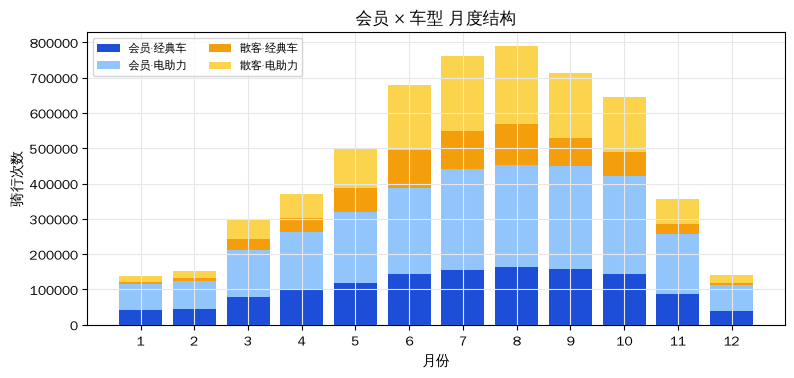

In [13]:
piv = cube.groupby(["month","member","bike"]).n.sum().unstack(["member","bike"]).fillna(0)
labels = {("member","classic_bike"):("会员·经典车",CBLUE), ("member","electric_bike"):("会员·电助力","#93C5FD"),
          ("casual","classic_bike"):("散客·经典车",CAMBER), ("casual","electric_bike"):("散客·电助力","#FCD34D")}
fig, ax = plt.subplots(figsize=(9, 3.8))
bottom = np.zeros(len(piv))
for key,(lab,c) in labels.items():
    if key in piv.columns: ax.bar(piv.index, piv[key], bottom=bottom, color=c, label=lab); bottom += piv[key].values
ax.set_xticks(piv.index); ax.set_xlabel("月份"); ax.set_ylabel("骑行次数")
ax.set_title("会员 × 车型 月度结构"); ax.legend(fontsize=8, ncol=2); plt.show()

In [14]:
g = cube.groupby(["member","bike"]).agg(n=("n","sum"), s=("sum_min","sum"))
avg = g.s / g.n
display(avg.round(1).to_frame("平均时长(分钟)"))
print(f"电助力车站外还车比例: {kpi.electric_offstation_pct}%")

平均时长(分钟)
member bike                   
casual classic_bike       29.3
       electric_bike      14.0
member classic_bike       13.6
       electric_bike      11.0

电助力车站外还车比例: 34.3%


## 7. 结论

1. **通勤主导**:工作日 8/17 时双峰 + 会员短时长结构,说明 Divvy 承载大量通勤需求;
2. **休闲需求**:散客周末 12–17 时单峰、时长更长,集中在滨湖与旅游走廊;
3. **空间潮汐**:净流入/流出站点固定,早晚高峰间需要定向调度;电助力站外还车进一步推高调度成本;
4. **局限**:无用户 ID(不能算留存/复购),无天气与事件数据(季节性归因待交叉验证);
5. **展望**:Structured Streaming 实时大屏、结合天气/POI 的需求预测与调度优化。

> 复现:先运行 `00_download_data.py` → `01_clean_etl.py` → `02_build_metrics.py`,
> 然后 `DATA_ROOT=./warehouse` 重新执行本笔记本。